# Download CUAD and map 41 clause types to good/neutral/bad

In [1]:
# Install the Hugging Face library
!pip install datasets==2.19.1 -q

In [2]:
import re
import pandas as pd
from datasets import load_dataset

In [3]:
# 1. Fetching CUAD dataset directly from Hugging Face
hf_dataset = load_dataset("theatticusproject/cuad-qa", split="train", trust_remote_code=True)
df = pd.DataFrame(hf_dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/22450 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4182 [00:00<?, ? examples/s]

In [4]:
# 2. Extract the actual Clause Type from the Question string
# We use regex to grab the exact clause name hidden inside the question
def extract_category(question_text):
    match = re.search(r'related to "(.*?)" that should', str(question_text))
    if match:
        return match.group(1)
    return 'Other'

df['original_label'] = df['question'].apply(extract_category)

In [5]:
# 3. Extract the actual Clause Text from the Answers dictionary
def extract_text(answer_dict):
    if len(answer_dict['text']) > 0:
        return answer_dict['text'][0] # Grab the first found clause
    return None

df['clause_text'] = df['answers'].apply(extract_text)

# Drop any rows where a clause was not actually found in the document
df = df.dropna(subset=['clause_text'])

In [6]:
# 4. Define our exact mapping dictionary for CUAD categories
# We map protective clauses to 'good', standard boilerplate to 'neutral', and restrictive clauses to 'bad'
cuad_mapping = {
    'Cap on Liability': 'good',
    'Notice Period To Terminate': 'good',
    'Document Name': 'neutral',
    'Parties': 'neutral',
    'Agreement Date': 'neutral',
    'Effective Date': 'neutral',
    'Governing Law': 'neutral',
    'Uncapped Liability': 'bad',
    'Non-Compete': 'bad',
    'Exclusivity': 'bad',
    'Termination for Convenience': 'bad',
    'Irrevocable Or Perpetual License': 'bad'
}

# Map the labels. We default any unlisted standard corporate clauses to 'neutral'
df['label'] = df['original_label'].map(lambda x: cuad_mapping.get(x, 'neutral'))
df['dataset'] = 'CUAD'

In [7]:
# 5. Clean up and export
final_df = df[['clause_text', 'original_label', 'label', 'dataset']]
final_df.to_csv('cuad_mapped_hf.csv', index=False)

print("\n--- Pipeline Execution Successful ---")
print(f"Total valid clauses processed: {len(final_df)}")
print("\nClass Breakdown:")
print(final_df['label'].value_counts())


--- Pipeline Execution Successful ---
Total valid clauses processed: 11180

Class Breakdown:
label
neutral    10355
bad          825
Name: count, dtype: int64


In [8]:
from google.colab import files

files.download('cuad_mapped_hf.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Total Unique Categories Found: 41

--- Top 15 Most Common Legal Clauses ---
original_label
Parties                      2011
License Grant                 642
Cap On Liability              554
Audit Rights                  538
Anti-Assignment               517
Insurance                     443
Document Name                 419
Expiration Date               384
Agreement Date                383
Governing Law                 374
Post-Termination Services     368
Effective Date                363
Minimum Commitment            336
Exclusivity                   332
Revenue/Profit Sharing        331
Name: count, dtype: int64




/tmp/ipykernel_28115/716971565.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.head(15).values, y=category_counts.head(15).index, palette='viridis')


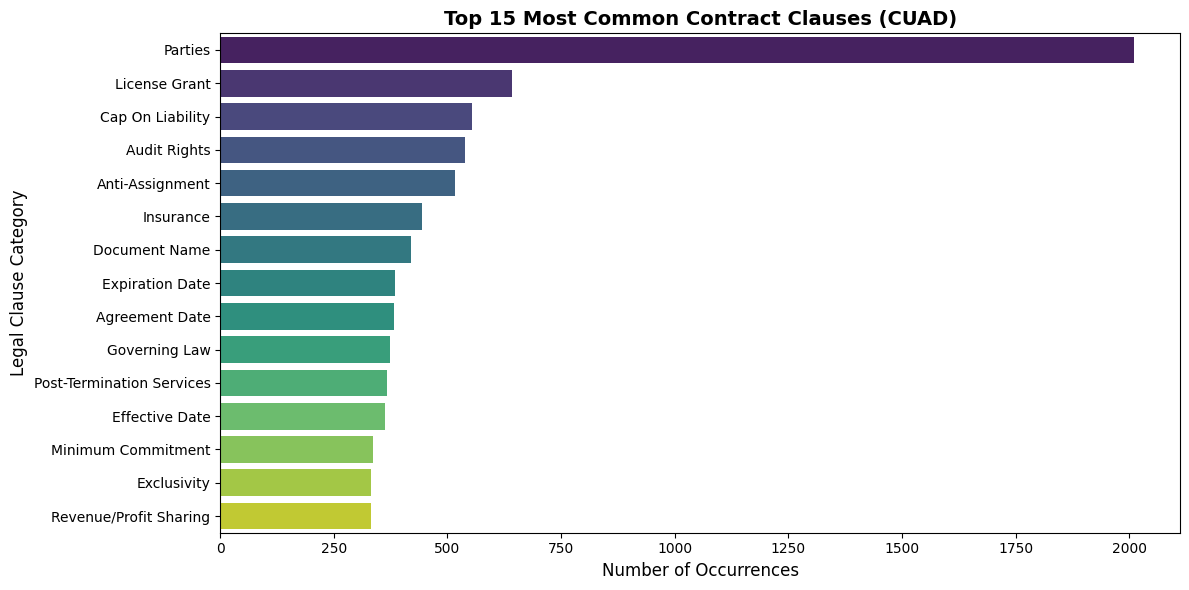

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the file you just generated
df = pd.read_csv('cuad_mapped_hf.csv')

# 2. Count the occurrences of the original 41 lawyer categories
category_counts = df['original_label'].value_counts()

print(f"Total Unique Categories Found: {len(category_counts)}\n")
print("--- Top 15 Most Common Legal Clauses ---")
print(category_counts.head(15))
print("\n" + "="*50 + "\n")

# 3. Create a clean horizontal bar chart for the Top 15
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.head(15).values, y=category_counts.head(15).index, palette='viridis')

plt.title('Top 15 Most Common Contract Clauses (CUAD)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Legal Clause Category', fontsize=12)
plt.tight_layout()
plt.show()